# LOAD LIBRARIES

In [1]:
import os
import math
import numpy as np
import scipy
import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
from datetime import datetime
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
import scipy.stats as stats
import sys
import matplotlib.dates as mdates
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score

In [2]:
# Project settings (dataset period, data paths): see src/config.py
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import DATA_DIR, PERIOD_START, PERIOD_END, select_period
print(f"Dataset period: {PERIOD_START} to {PERIOD_END} (CET, UTC+1)")

Dataset period: 2024-08-22 00:00:00 to 2025-06-05 00:00:00 (CET, UTC+1)


# READ DATA

## STATION DATA

select_period: kept 13776 of 26601 records (2024-08-22 00:30:00+01:00 to 2025-06-05 00:00:00+01:00, timestamp=end)


,g,pa,ppfd,prec,rh,swc_0.05,swc_0.15,swc_0.3,swc_0.05_soilvue,swc_0.1_soilvue,...,ts_0.05_soilvue,ts_0.1_soilvue,ts_0.2_soilvue,ts_0.3_soilvue,ts_0.4_soilvue,ts_0.5_soilvue,sw_in,sw_out,lw_in,lw_out
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:30:00+01:00,-37.436829,95.590000,0.0,0.000,89.440002,16.752412,26.141747,23.278843,4.033374,3.308948,...,16.896103,18.604869,19.979177,20.470648,20.189522,20.017630,0.0,0.0,287.964170,359.007210
2024-08-22 01:00:00+01:00,-36.883657,95.579000,0.0,0.000,90.133334,16.707313,26.144934,23.268508,4.039357,3.321869,...,16.669101,18.398698,19.858460,20.424261,20.183070,20.017630,0.0,0.0,290.714810,358.990830
2024-08-22 01:30:00+01:00,-34.570664,95.556333,0.0,0.000,90.923334,16.672328,26.134158,23.272999,3.957934,3.311942,...,16.500323,18.211077,19.741767,20.377010,20.168355,20.017630,0.0,0.0,290.553243,358.851063
2024-08-22 02:00:00+01:00,-33.094323,95.527000,0.0,0.000,91.986667,16.611719,26.123198,23.264485,3.954666,3.235909,...,16.353953,18.040923,19.624526,20.327973,20.155480,20.017630,0.0,0.0,289.408103,358.216177
2024-08-22 02:30:00+01:00,-32.885476,95.500000,0.0,0.000,91.233334,16.552405,26.132820,23.234120,3.926762,3.272310,...,16.189802,17.890575,19.513076,20.277152,20.135225,20.013053,0.0,0.0,291.432023,357.531653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:00:00+01:00,-23.907052,95.134000,0.0,0.017,82.700000,27.981393,29.086370,24.709643,18.329227,18.018475,...,17.638945,18.094945,18.042643,17.669967,16.876580,16.297180,0.0,0.0,365.498643,392.441257
2025-06-04 22:30:00+01:00,-22.316862,95.139333,0.0,0.034,84.423333,27.982679,29.086370,24.707201,18.053377,18.021240,...,17.515017,17.955672,17.975648,17.650989,16.876580,16.302190,0.0,0.0,368.483990,391.171820
2025-06-04 23:00:00+01:00,-21.379620,95.165333,0.0,0.425,83.819999,27.975655,29.082396,24.680151,18.172180,17.937464,...,17.408629,17.835954,17.909638,17.639782,16.877426,16.318055,0.0,0.0,367.879707,392.245203


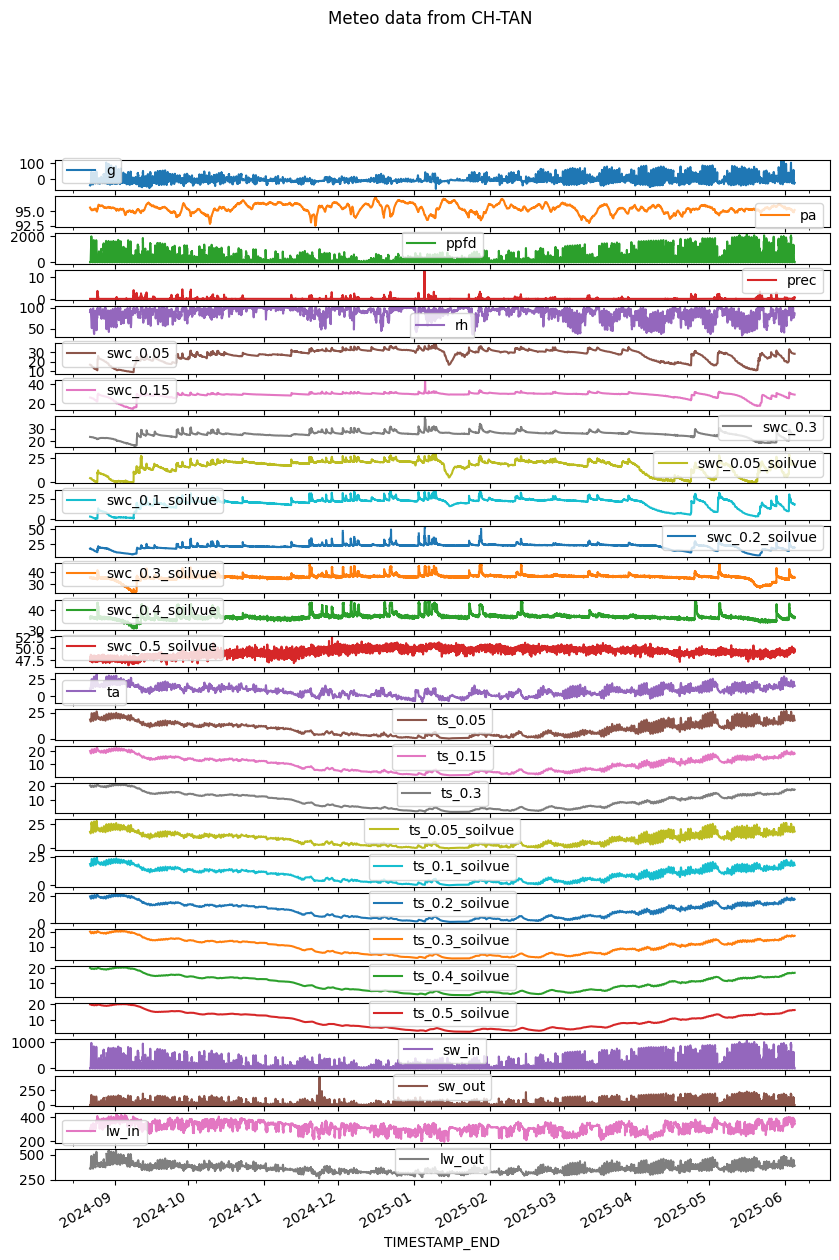

In [3]:
meteo = pd.read_csv('11.1_CH-TAN_meteo_meteoscreening_diive.csv')
meteo['TIMESTAMP_END'] = pd.to_datetime(meteo['TIMESTAMP_END'], format='%Y-%m-%d %H:%M:%S')
meteo.set_index('TIMESTAMP_END', inplace=True)
meteo.index = meteo.index.tz_localize('Etc/GMT-1')
meteo = select_period(meteo, timestamp='end')  # restrict to the dataset period
meteo.plot(subplots=True, x_compat=True, figsize=(10, 15), title='Meteo data from CH-TAN');
meteo

## METEOSWISS DATA

- tre200s0 --> TA at 2 m in °C
- ure200s0 --> RH at 2m
- prestas0 --> PA in hPa
- fve010z0 --> WS in m/s vectorial mean
- fkl010z0 --> WS in m/s scalar mean
- dkl010z0 --> WD in degrees
- rre150z0 --> P in mm
- gre000z0 --> global radiation in w/m2
- ods000z0 --> diffuse radiation in w/m2
- oli000z0 --> LW_IN in w/m2
- olo000z0 --> LW_OUT in w/m2
- osr000z0 --> SW_OUT in w/m2

select_period: kept 13776 of 13781 records (2024-08-22 00:30:00+01:00 to 2025-06-05 00:00:00+01:00, timestamp=end)


,TA,RH,PA,PREC,SW_IN,SW_OUT,LW_IN,LW_OUT
timestamp,,,,,,,,
2024-08-22 00:30:00+01:00,10.733333,90.566667,95.636667,0.0,1.333333,-5.000000,301.333333,357.333333
2024-08-22 01:00:00+01:00,10.766667,90.000000,95.630000,0.0,1.333333,-4.666667,303.000000,356.333333
2024-08-22 01:30:00+01:00,10.566667,91.033333,95.610000,0.0,1.333333,-5.000000,304.666667,356.666667
2024-08-22 02:00:00+01:00,10.500000,91.933333,95.580000,0.0,1.000000,-4.666667,304.000000,355.000000
2024-08-22 02:30:00+01:00,10.566667,91.433333,95.556667,0.0,1.000000,-5.000000,305.000000,352.666667
...,...,...,...,...,...,...,...,...
2025-06-04 22:00:00+01:00,15.766667,75.600000,95.183333,0.0,0.000000,-4.000000,369.000000,386.333333
2025-06-04 22:30:00+01:00,15.533333,78.300000,95.190000,0.0,0.666667,-4.666667,371.666667,386.333333
2025-06-04 23:00:00+01:00,15.766667,76.700000,95.216667,0.0,0.000000,-4.000000,370.666667,386.666667


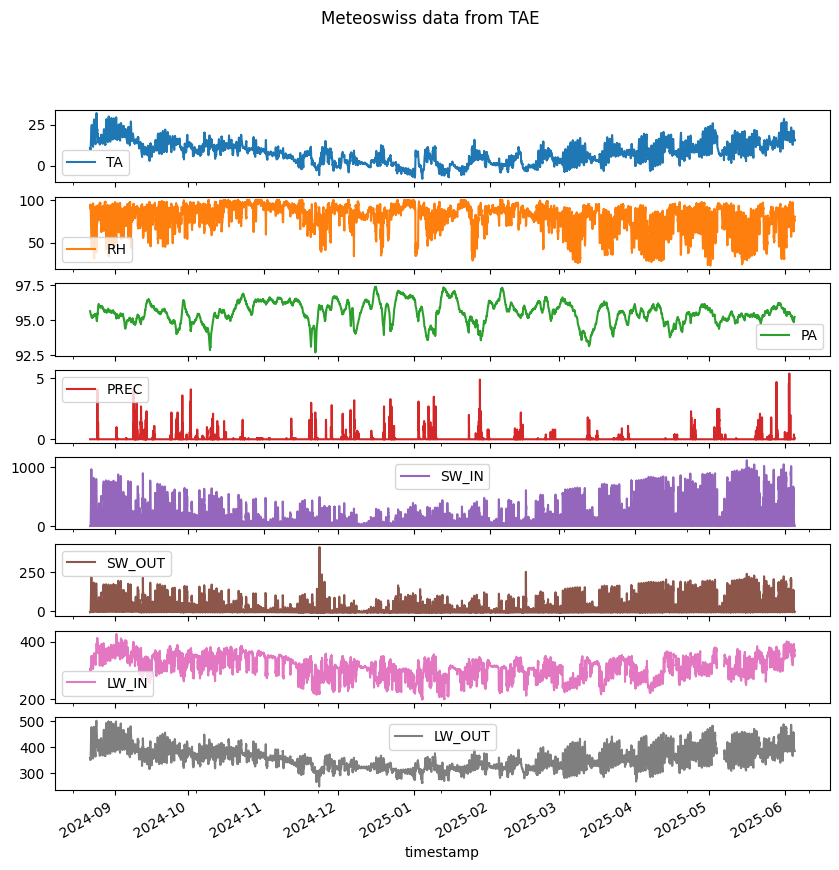

In [4]:
meteoswiss = pd.read_csv(Path('meteoswiss') / 'meteoswiss_TAE_meteo_2020-2029.csv', delimiter=';')
meteoswiss_2025 = pd.read_csv(Path('meteoswiss') / 'meteoswiss_TAE_meteo_2025.csv', delimiter=';')
meteoswiss = pd.concat([meteoswiss, meteoswiss_2025], ignore_index=True)
rename_dict = {
    'reference_timestamp': 'timestamp',
    'tre200s0': 'TA',
    'ure200s0': 'RH',
    'prestas0': 'PA',
    'rre150z0': 'PREC',
    'gre000z0': 'SW_IN',
    'osr000z0': 'SW_OUT',
    'oli000z0': 'LW_IN',
    'olo000z0': 'LW_OUT',
}
meteoswiss.rename(columns=rename_dict, inplace=True)
meteoswiss = meteoswiss[[col for col in rename_dict.values()]]
meteoswiss['timestamp'] = pd.to_datetime(meteoswiss['timestamp'], format='%d.%m.%Y %H:%M')
meteoswiss.set_index('timestamp', inplace=True)
# Convert meteoswiss timestamps to UTC+1
meteoswiss.index = meteoswiss.index.tz_localize('UTC').tz_convert('Etc/GMT-1')

# Change unit for atmospheric pressure from hPa to kgPa
meteoswiss['PA'] = meteoswiss['PA'] / 10.0  # Convert hPa to kPa

# Restrict to the dataset period (1 h margin so that the first 30-min means are complete)
meteoswiss = meteoswiss[str(PERIOD_START - pd.Timedelta('1h')):str(PERIOD_END + pd.Timedelta('1h'))]

# Resample 10-min to 30-min, summing 'PREC' and averaging other columns
meteoswiss = meteoswiss.resample('30min', label='right', closed='right').agg({
    'TA': 'mean',
    'RH': 'mean',
    'PA': 'mean',
    'PREC': 'sum',
    'SW_IN': 'mean',
    'SW_OUT': 'mean',
    'LW_IN': 'mean',
    'LW_OUT': 'mean'
})
meteoswiss = select_period(meteoswiss, timestamp='end')  # drop the margin again

meteoswiss.plot(subplots=True, x_compat=True, figsize=(10, 10), title='Meteoswiss data from TAE');
meteoswiss

Linear model to calculate ppfd from sw_in because it was not measured by Meteoswiss

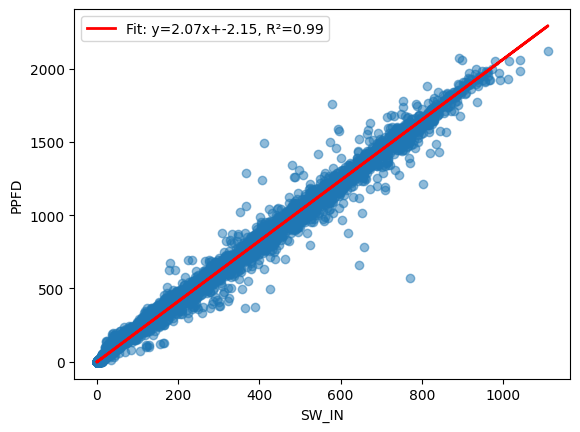

In [5]:
# Align the two series by index (inner join keeps only common timestamps)
df = meteoswiss[['SW_IN']].join(meteo[['ppfd']], how='inner')

# Drop NaNs
df = df.dropna()

x = df['SW_IN'].values.reshape(-1, 1)
y = df['ppfd'].values

# Fit robust regression
model = HuberRegressor().fit(x, y)
y_pred = model.predict(x)

# Equation and R²
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_pred)

# Plot
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_pred, color="red", lw=2, label=f"Fit: y={slope:.2f}x+{intercept:.2f}, R²={r2:.2f}")
plt.xlabel('SW_IN')
plt.ylabel('PPFD')
plt.legend()
plt.show()

# Create a new PPFD col using the linear model
meteoswiss['PPFD'] = model.predict(meteoswiss['SW_IN'].values.reshape(-1, 1))

## MERGE

In [6]:
meteo_merged = pd.merge(meteo, meteoswiss, left_index=True, right_index=True, how='outer')

meteo_merged

,g,pa,ppfd,prec,rh,swc_0.05,swc_0.15,swc_0.3,swc_0.05_soilvue,swc_0.1_soilvue,...,lw_out,TA,RH,PA,PREC,SW_IN,SW_OUT,LW_IN,LW_OUT,PPFD
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:30:00+01:00,-37.436829,95.590000,0.0,0.000,89.440002,16.752412,26.141747,23.278843,4.033374,3.308948,...,359.007210,10.733333,90.566667,95.636667,0.0,1.333333,-5.000000,301.333333,357.333333,0.600915
2024-08-22 01:00:00+01:00,-36.883657,95.579000,0.0,0.000,90.133334,16.707313,26.144934,23.268508,4.039357,3.321869,...,358.990830,10.766667,90.000000,95.630000,0.0,1.333333,-4.666667,303.000000,356.333333,0.600915
2024-08-22 01:30:00+01:00,-34.570664,95.556333,0.0,0.000,90.923334,16.672328,26.134158,23.272999,3.957934,3.311942,...,358.851063,10.566667,91.033333,95.610000,0.0,1.333333,-5.000000,304.666667,356.666667,0.600915
2024-08-22 02:00:00+01:00,-33.094323,95.527000,0.0,0.000,91.986667,16.611719,26.123198,23.264485,3.954666,3.235909,...,358.216177,10.500000,91.933333,95.580000,0.0,1.000000,-4.666667,304.000000,355.000000,-0.087866
2024-08-22 02:30:00+01:00,-32.885476,95.500000,0.0,0.000,91.233334,16.552405,26.132820,23.234120,3.926762,3.272310,...,357.531653,10.566667,91.433333,95.556667,0.0,1.000000,-5.000000,305.000000,352.666667,-0.087866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:00:00+01:00,-23.907052,95.134000,0.0,0.017,82.700000,27.981393,29.086370,24.709643,18.329227,18.018475,...,392.441257,15.766667,75.600000,95.183333,0.0,0.000000,-4.000000,369.000000,386.333333,-2.154209
2025-06-04 22:30:00+01:00,-22.316862,95.139333,0.0,0.034,84.423333,27.982679,29.086370,24.707201,18.053377,18.021240,...,391.171820,15.533333,78.300000,95.190000,0.0,0.666667,-4.666667,371.666667,386.333333,-0.776647
2025-06-04 23:00:00+01:00,-21.379620,95.165333,0.0,0.425,83.819999,27.975655,29.082396,24.680151,18.172180,17.937464,...,392.245203,15.766667,76.700000,95.216667,0.0,0.000000,-4.000000,370.666667,386.666667,-2.154209


# COMPARE DATASETS

During winter time

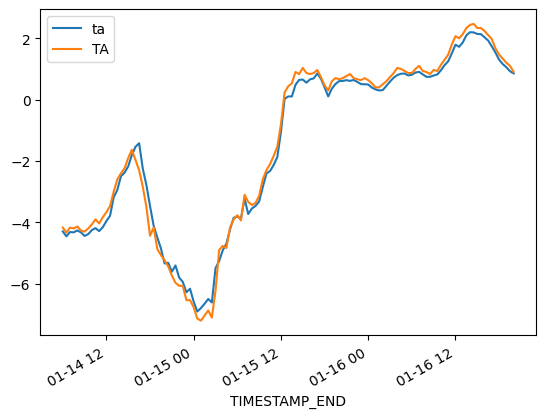

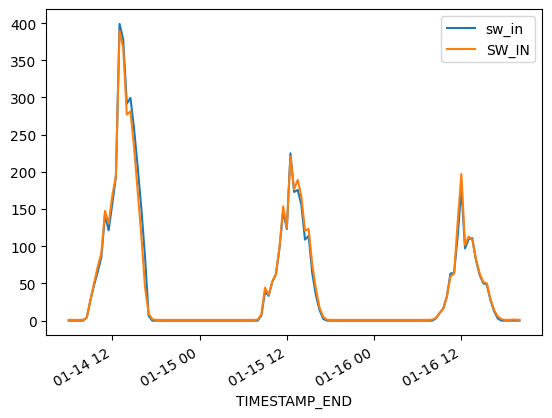

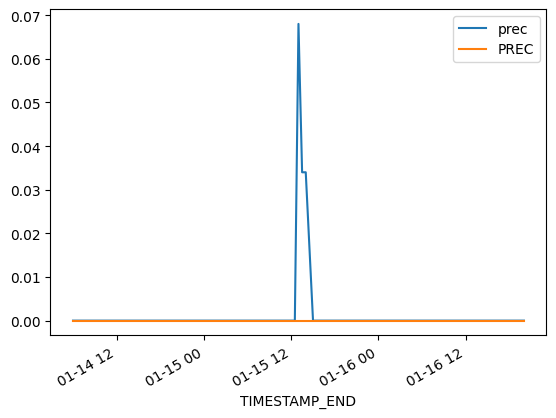

In [7]:
start_date = '2025-01-14 06:00'
end_date = '2025-01-16 20:00'
meteo_merged[start_date:end_date][['ta', 'TA']].plot(x_compat=True);
meteo_merged[start_date:end_date][['sw_in', 'SW_IN']].plot(x_compat=True);
meteo_merged[start_date:end_date][['prec', 'PREC']].plot(x_compat=True);

During late summer

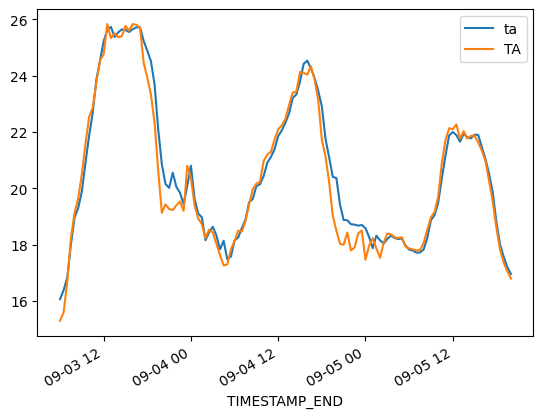

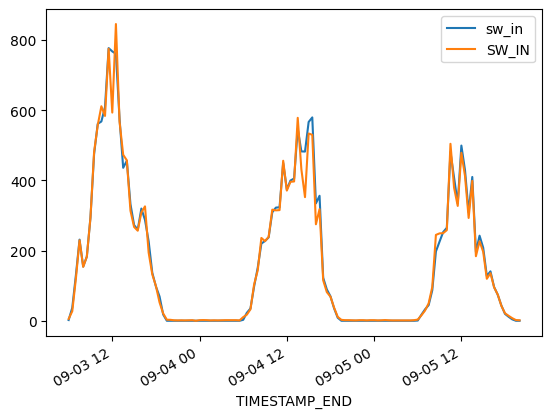

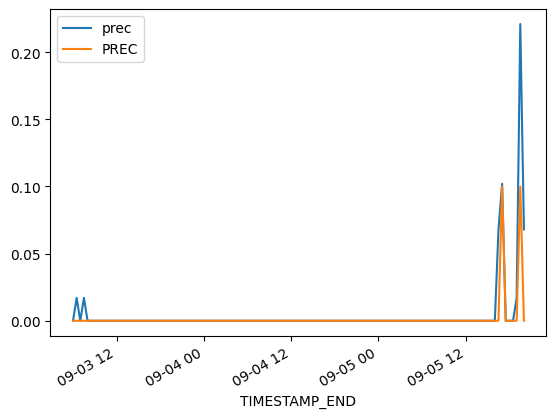

In [8]:
start_date = '2024-09-03 06:00'
end_date = '2024-09-05 20:00'
meteo_merged[start_date:end_date][['ta', 'TA']].plot(x_compat=True);
meteo_merged[start_date:end_date][['sw_in', 'SW_IN']].plot(x_compat=True);
meteo_merged[start_date:end_date][['prec', 'PREC']].plot(x_compat=True);

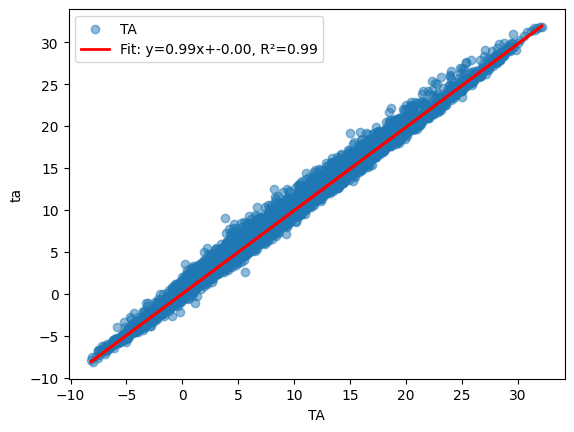

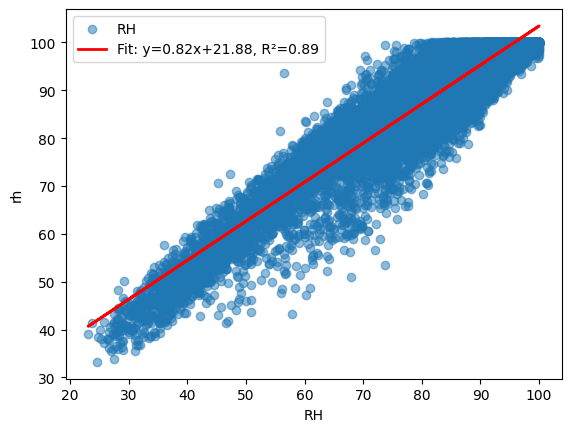

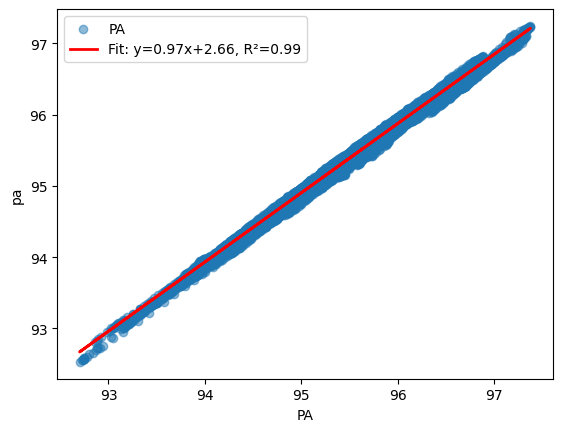

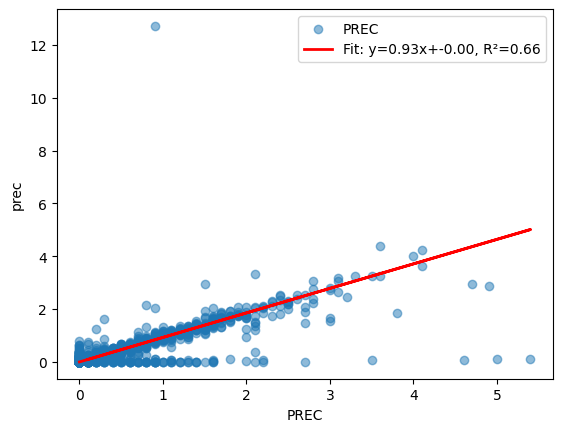

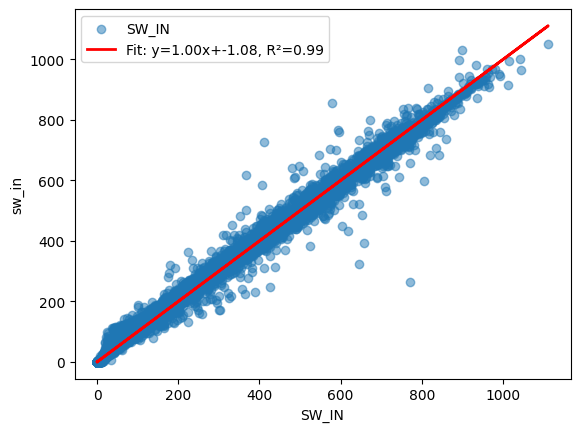

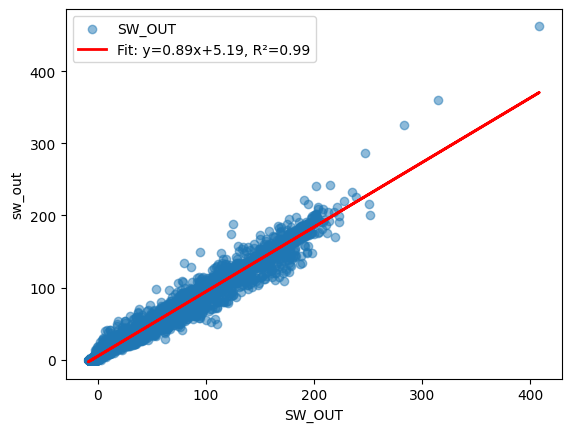

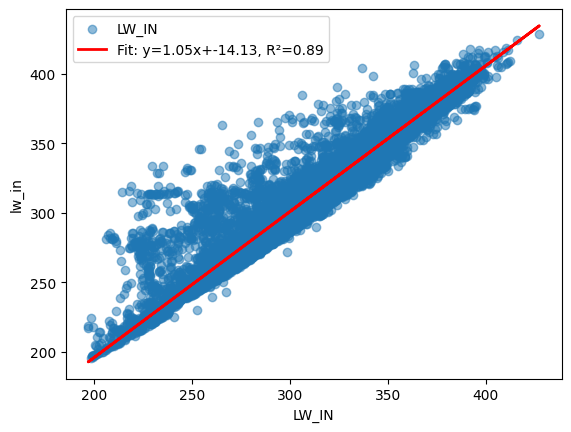

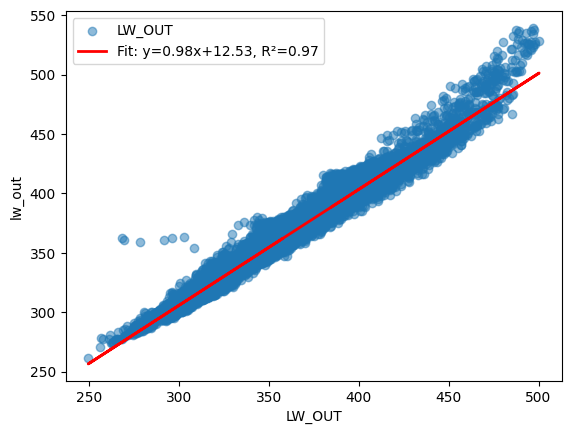

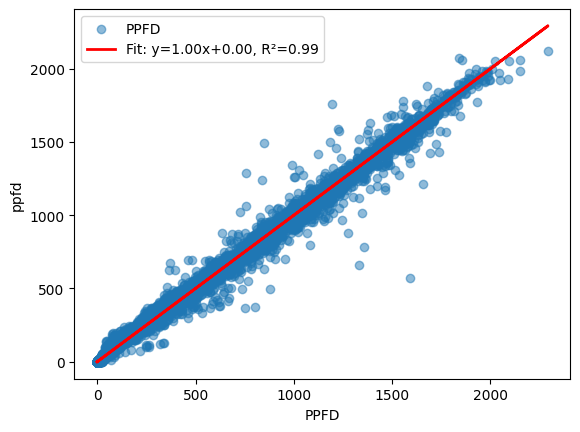

In [9]:
meteoswiss_vars = meteoswiss.columns.tolist()

for var in meteoswiss_vars:
    x = meteo_merged[var].values.reshape(-1, 1)
    y = meteo_merged[var.lower()].values

    # Drop NaNs
    mask = ~np.isnan(x.flatten()) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    # Fit robust regression
    model = HuberRegressor().fit(x, y)
    y_pred = model.predict(x)

    # Equation and R²
    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = r2_score(y, y_pred)

    # Plot
    plt.scatter(x, y, alpha=0.5, label=var)
    plt.plot(x, y_pred, color="red", lw=2, label=f"Fit: y={slope:.2f}x+{intercept:.2f}, R²={r2:.2f}")
    plt.xlabel(var)
    plt.ylabel(var.lower())
    plt.legend()
    plt.show()

# GAP-FILLING

Remaining NaNs per column:
g                         0
pa                        0
ppfd                      0
prec                      0
rh                        0
swc_0.05                  0
swc_0.15                  0
swc_0.3                   0
swc_0.05_soilvue          0
swc_0.1_soilvue           0
swc_0.2_soilvue          38
swc_0.3_soilvue           0
swc_0.4_soilvue           0
swc_0.5_soilvue           0
ta                        0
ts_0.05                   0
ts_0.15                   0
ts_0.3                    0
ts_0.05_soilvue           0
ts_0.1_soilvue            0
ts_0.2_soilvue            0
ts_0.3_soilvue            0
ts_0.4_soilvue            0
ts_0.5_soilvue            0
sw_in                     0
sw_out                    0
lw_in                     0
lw_out                    0
TA                        0
RH                        0
PA                        0
PREC                      0
SW_IN                     0
SW_OUT                    0
LW_IN                

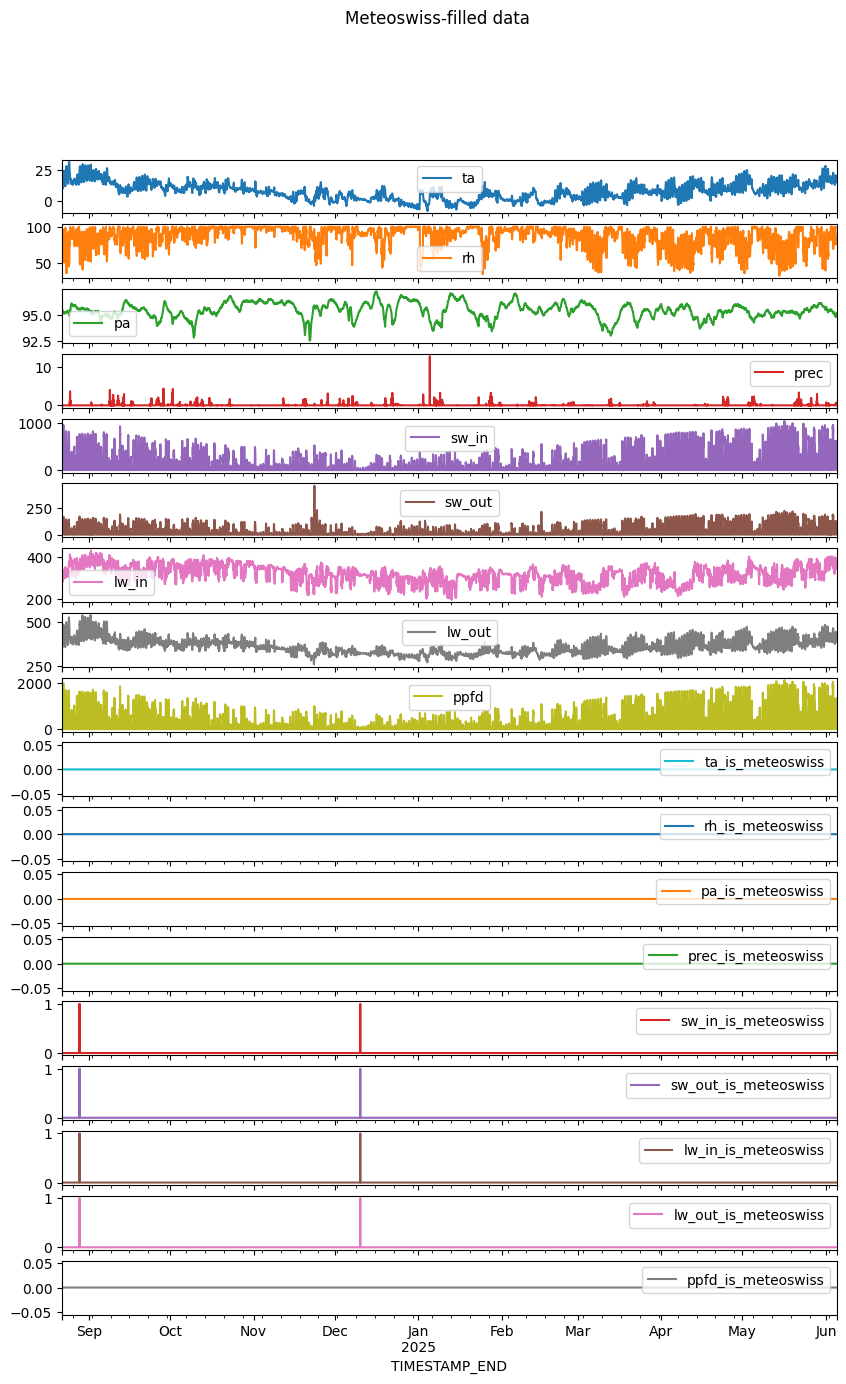

In [10]:
# Initialize a copy of the merged DataFrame to fill missing values
meteo_filled = meteo_merged.copy()

for var in meteoswiss_vars:
    lower_var = var.lower()
    flag_name = f"{lower_var}_is_meteoswiss"

    # Initialize flag column as False
    meteo_filled[flag_name] = 0

    # Values to fill (only where meteo_filled is NaN and meteoswiss has data)
    fill_mask = meteo_filled[lower_var].isna() & meteoswiss[var].notna()

    # Fill values
    meteo_filled.loc[fill_mask, lower_var] = meteoswiss.loc[fill_mask, var]

    # Mark fills
    meteo_filled.loc[fill_mask, flag_name] = 1

# Check remaining missing values
print("Remaining NaNs per column:")
print(meteo_filled.isna().sum())

# Select only the variables that exist in both datasets
cols_meteo_filled = [c.lower() for c in meteoswiss_vars]
flags = [c for c in meteo_filled.columns if c.endswith('_is_meteoswiss')]
to_plot = cols_meteo_filled + flags

meteo_filled[to_plot].plot(
    subplots=True, 
    figsize=(10, 15), 
    title='Meteoswiss-filled data'
);

# EXPORT GAP-FILLED DATA

In [11]:
meteo_filled.drop(columns=meteoswiss_vars, inplace=True)  # Drop the columns used for filling

# EXPORT GAP-FILLED DATA
# This is the input file of the published dataset (contains MeteoSwiss data, flagged in *_is_meteoswiss; Source: MeteoSwiss)
output_file = DATA_DIR / 'METEO' / 'CH-TAN_meteo_gapfilled-meteoswiss_2024-25.csv'
output_file.parent.mkdir(parents=True, exist_ok=True)
meteo_filled.reset_index(names='TIMESTAMP_END').to_csv(output_file, index=False)
print(f"Gap-filled data exported to {output_file}")

Gap-filled data exported to C:\Users\turcof\Desktop\TAN\dataset_ch-tan_ley_2024-25_flux_product\data\METEO\CH-TAN_meteo_gapfilled-meteoswiss_2024-25.csv


# End of notebook

In [12]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-10-06 15:20:01
